# 03 – Exploratory Data Analysis (EDA)

U ovom dijelu analiziraju se karakteristike korisnika i njihove veze s odustajanjem (churn).  
Cilj je identificirati ključne faktore koji utječu na odlazak korisnika.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


possible_paths = [
    Path("data/Telco_customer_clean.csv"),
    Path("../data/Telco_customer_clean.csv"),
    Path("/content/drive/MyDrive/csv/Telco_customer_clean.csv")
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

df = pd.read_csv(DATA_PATH)
print("Using data file:", DATA_PATH.resolve())
df.shape



Using data file: /content/drive/MyDrive/csv/Telco_customer_clean.csv


(7043, 23)

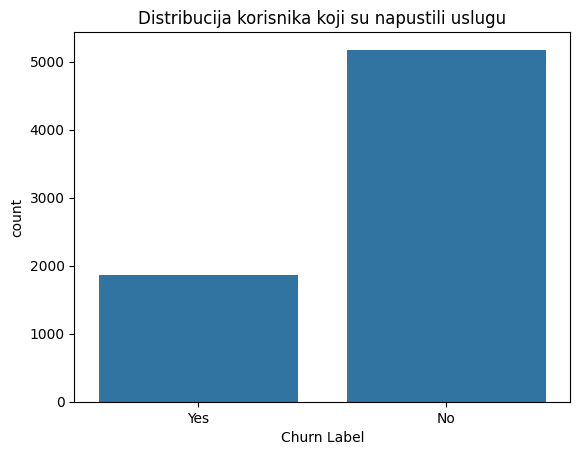

In [4]:
sns.countplot(x="Churn Label", data=df)
plt.title("Distribucija korisnika koji su napustili uslugu")
plt.show()

Većina korisnika, oko 73.5%, nije napustila uslugu, dok je oko 26.5% korisnika napustilo.  
To ukazuje na umjerenu neuravnoteženost klasa, što treba uzeti u obzir pri modeliranju.


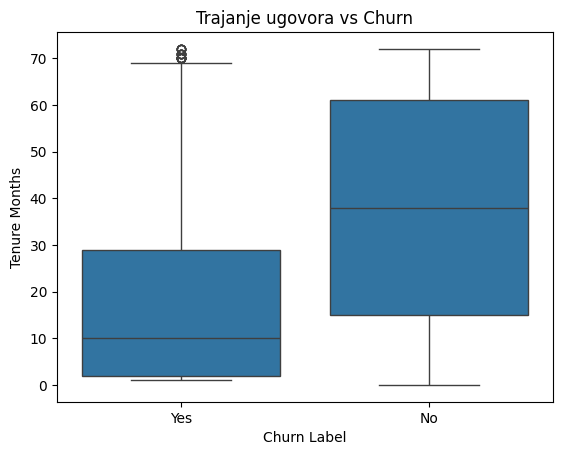

In [ ]:
sns.boxplot(x="Churn Label", y="Tenure Months", data=df)
plt.title("Trajanje ugovora vs Churn")
plt.show()

Korisnici koji napuštaju uslugu imaju kraći prosječni period korištenja usluge.  
To sugerira da je trajanje ugovora važan faktor u predikciji churn-a.


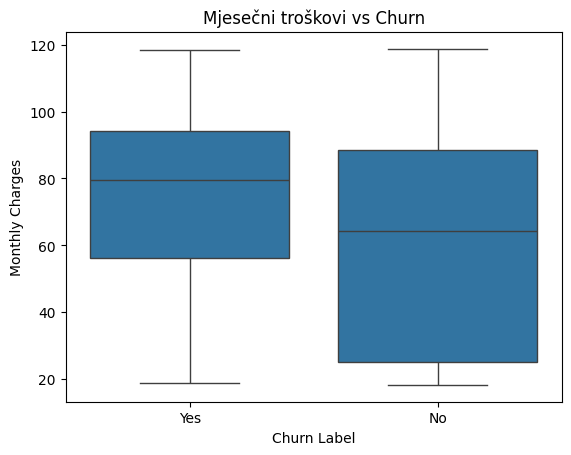

In [ ]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Mjesečni troškovi vs Churn")
plt.show()


Korisnici s višim mjesečnim troškovima češće napuštaju uslugu, što može ukazivati na osjetljivost na cijenu.
To sugerira da visoka cijena paketa može biti jedan od ključnih faktora koji utječe na odlazak korisnika.

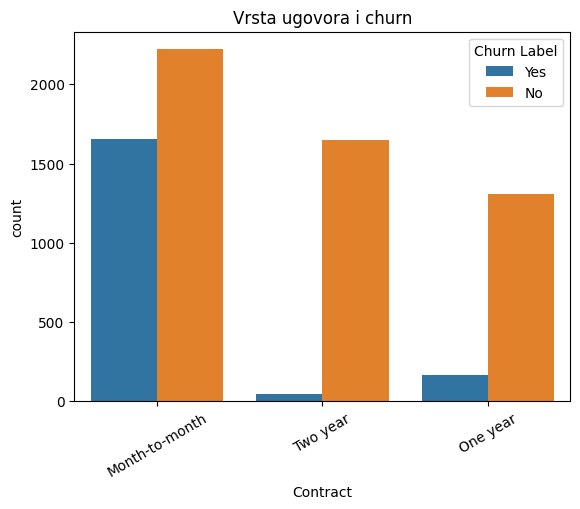

In [ ]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.xticks(rotation=30)
plt.title("Vrsta ugovora i churn")
plt.show()


Graf pokazuje odnos između vrste ugovora i odlaska korisnika (churn).

Korisnici s mjesečnim ugovorom (Month-to-month) imaju znatno veću stopu churn-a u usporedbi s korisnicima koji imaju jednogodišnje ili dvogodišnje ugovore.  
Dugoročni ugovori (One year i Two year) značajno smanjuju vjerojatnost odlaska korisnika, što potvrđuje važnost ugovorne obveze u zadržavanju korisnika.


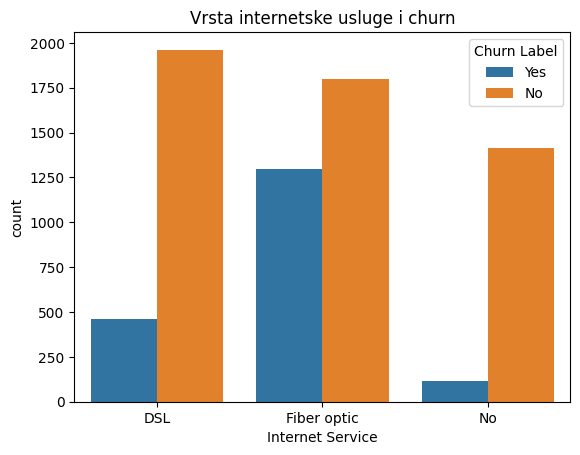

In [ ]:
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Vrsta internetske usluge i churn")
plt.show()


Graf prikazuje odnos između vrste internetske usluge i churn-a.

Korisnici koji koriste Fiber optic internet imaju veću stopu churn-a u odnosu na korisnike s DSL uslugom ili bez usluge.  
To može ukazivati na veća očekivanja korisnika fiber optičkih usluga ili nezadovoljstvo cijenom i kvalitetom usluge.


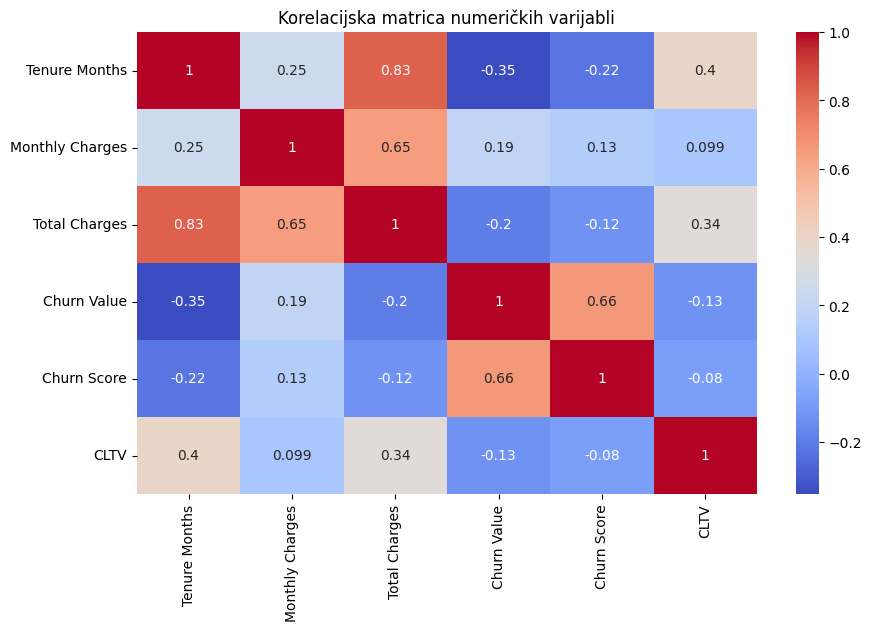

In [ ]:
num_cols = df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(10,6))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Korelacijska matrica numeričkih varijabli")
plt.show()


## Korelacijska analiza numeričkih varijabli

Korelacijska matrica prikazuje linearne odnose između numeričkih varijabli u datasetu.

Najvažniji rezultati:
- Postoji vrlo jaka pozitivna korelacija između **Tenure Months** i **Total Charges**, što je očekivano jer korisnici koji dulje koriste uslugu akumuliraju veće ukupne troškove.
- **Monthly Charges** imaju slabu pozitivnu korelaciju s **Churn Value**, što sugerira da korisnici s višim mjesečnim troškovima imaju veću vjerojatnost odlaska.
- **Tenure Months** ima negativnu korelaciju s **Churn Value**, što znači da novi korisnici češće napuštaju uslugu nego dugoročni korisnici.
- Varijabla **Churn Score** pokazuje jaku korelaciju s **Churn Value**, što potvrđuje da je score dizajniran kao indikator rizika odlaska korisnika.


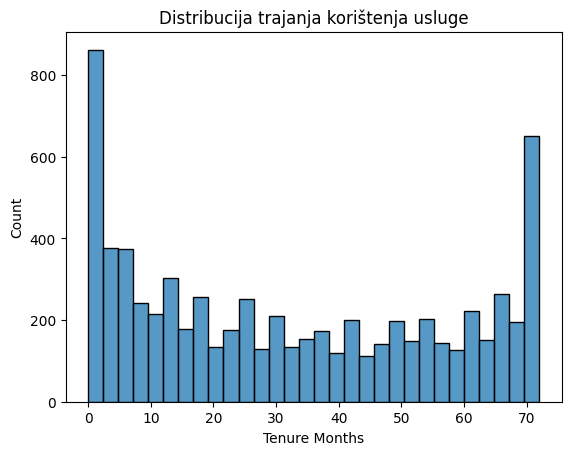

In [ ]:
sns.histplot(df["Tenure Months"], bins=30)
plt.title("Distribucija trajanja korištenja usluge")
plt.show()


Histogram pokazuje da veliki broj korisnika ima vrlo kratko ili vrlo dugo razdoblje korištenja usluge.  
To sugerira da korisnici ili brzo napuštaju uslugu ili ostaju dugoročni korisnici.  

EDA analiza pokazuje da churn najviše ovisi o trajanju korištenja usluge, vrsti ugovora i mjesečnim troškovima, što je u skladu s očekivanjima telekom industrije.
